## Important Data handling note:

To keep trials modular and easy to switch around while doing this EDA, I built the module `data_handling.py` which contains my data cleaning steps within `def __init__` within `MrozHandler` as follows:

```
class MrozHandler:
    def __init__(self, filepath):
        self.filepath = filepath
        
        self.full = (
            pd.read_csv(self.filepath) # read file
            .reset_index() 
            .set_index("index", drop=True) 
            .rename_axis("ObservationID") 
            .drop(columns=["Unnamed: 0"]) 
        ).rename(
            columns={ # change to the common variable names used in literature
                "experience": "exper", 
                "educw": "educ", 
                "child6": "kidslt6",
                "educwm": "motheduc",
                "educwf": "fatheduc",
            }
        )

        self.full["nwifeinc"] = (
            calculate_husband_income(self.full["wageh"], self.full["hoursh"]) / 1000 # initialize non-wife income as a column, key decider of labor participation
        )
        self.full["exper_c"] = self.full["exper"] - self.full["exper"].mean() # center experience
        self.full["expersq"] = self.full["exper_c"] ** 2 # initialize centered experience squared, (used to show diminishing returns)
        self.full["lwage"] = np.log(self.full["hearnw"].replace(0, np.nan)) # for statsmodel handling - 
        self.full["work"] = self.full["work"].map({"yes": 1, "no": 0}).astype(int) # broken bools
        self.full["city"] = self.full["city"].map({"yes": 1, "no": 0}).astype(int)
        self.working = self.full[self.full["work"].astype(bool)].copy().astype(int) # initialize working subset
        
        # debug print

        frows, ffeatures = self.full.shape 
        wrows, wfeatures = self.working.shape

        print("Full dataset shape")
        print(f"Number of rows: {frows}")
        print(f"Number of features: {ffeatures}")
        print("Working subset shape:")
        print(f"Number of rows: {wrows}")
        print(f"Number of features: {wfeatures}")

        self.dependent = None # used to store Y var series
        self.independents = [] # major X var series
        self.controls = [] # controlling var series
```

---

# CODE

---

# Project 1 - Phase 2: Data Audit & Forensics

Ian Solberg

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from data_handling import MrozHandler

Mroz = MrozHandler(filepath="data/Mroz.csv")

print(Mroz.full.describe())
print(Mroz.full.info())

Mroz.clear_caches()

Full dataset shape
Number of rows: 753
Number of features: 22
Working subset shape:
Number of rows: 428
Number of features: 22
             work       hoursw     kidslt6    child618        agew  \
count  753.000000   753.000000  753.000000  753.000000  753.000000   
mean     0.568393   740.576361    0.237716    1.353254   42.537849   
std      0.495630   871.314216    0.523959    1.319874    8.072574   
min      0.000000     0.000000    0.000000    0.000000   30.000000   
25%      0.000000     0.000000    0.000000    0.000000   36.000000   
50%      1.000000   288.000000    0.000000    1.000000   43.000000   
75%      1.000000  1516.000000    0.000000    2.000000   49.000000   
max      1.000000  4950.000000    3.000000    8.000000   60.000000   

             educ      hearnw       wagew       hoursh        ageh  ...  \
count  753.000000  753.000000  753.000000   753.000000  753.000000  ...   
mean    12.286853    2.374565    1.849734  2267.270916   45.120850  ...   
std      2.280246

In [2]:
Mroz.set_dependent("lwage")

Dependent variable set to: lwage


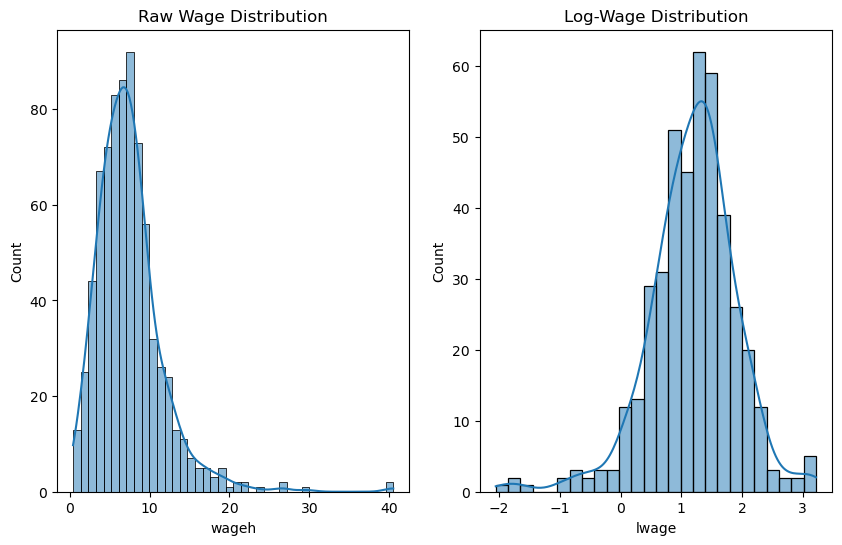

In [3]:
plt.figure(figsize=(10, 6))

plt.subplot(1, 2, 1)
sns.histplot(Mroz.full["wageh"], kde=True)
plt.title("Raw Wage Distribution")

plt.subplot(1, 2, 2)
sns.histplot(Mroz.dependent, kde=True)
plt.title("Log-Wage Distribution")

plt.show()

In [4]:
Mroz.clear_caches() # clear api cache

import statsmodels.api as sm
from scipy.stats import norm

# calculate IMR (Probability vector of choosing to work) using Probit:

Mroz.set_dependent("work", full=True)
Mroz.add_independents("kidslt6", "nwifeinc", "educ", "agew", "motheduc", "fatheduc", full=True)
probit_result = sm.Probit(Mroz.get_y().astype(int), Mroz.get_X()).fit()
fitted = probit_result.fittedvalues
imr_values = norm.pdf(fitted) / norm.cdf(fitted)
imr_series = pd.Series(imr_values, index=Mroz.full.index)


Mroz.attach("IMR", imr_series, to_working=True) # attach result


# initialize for requirements 2 and 3
Mroz.clear_caches()
Mroz.set_dependent("lwage", full=False)
Mroz.add_independents("exper", "expersq", full=False)
Mroz.add_controls("educ", "kidslt6", "nwifeinc", "IMR", full=False)

Caches cleared
Dependent variable set to: work
Independent variables: ['kidslt6', 'nwifeinc', 'educ', 'agew', 'motheduc', 'fatheduc']
Optimization terminated successfully.
         Current function value: 0.603822
         Iterations 5
Attached 'IMR' to dataset
Caches cleared
Dependent variable set to: lwage
Independent variables: ['exper', 'expersq']
Control variables: ['educ', 'kidslt6', 'nwifeinc', 'IMR']


## Requirement 2: The Bivariate Relationship (The "Eyeball Test")

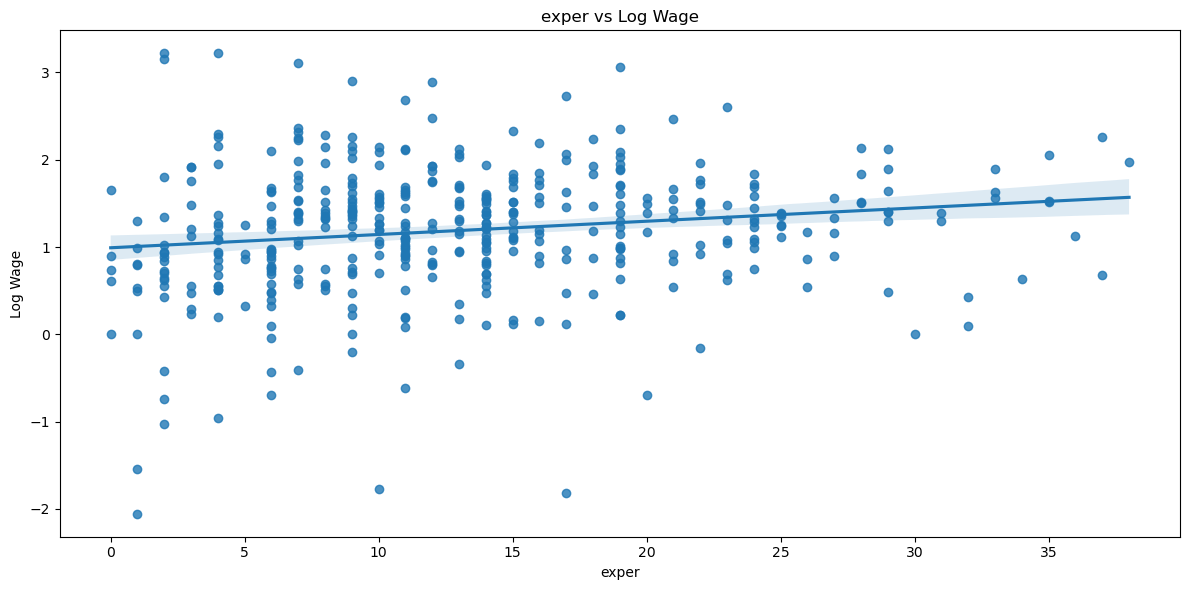

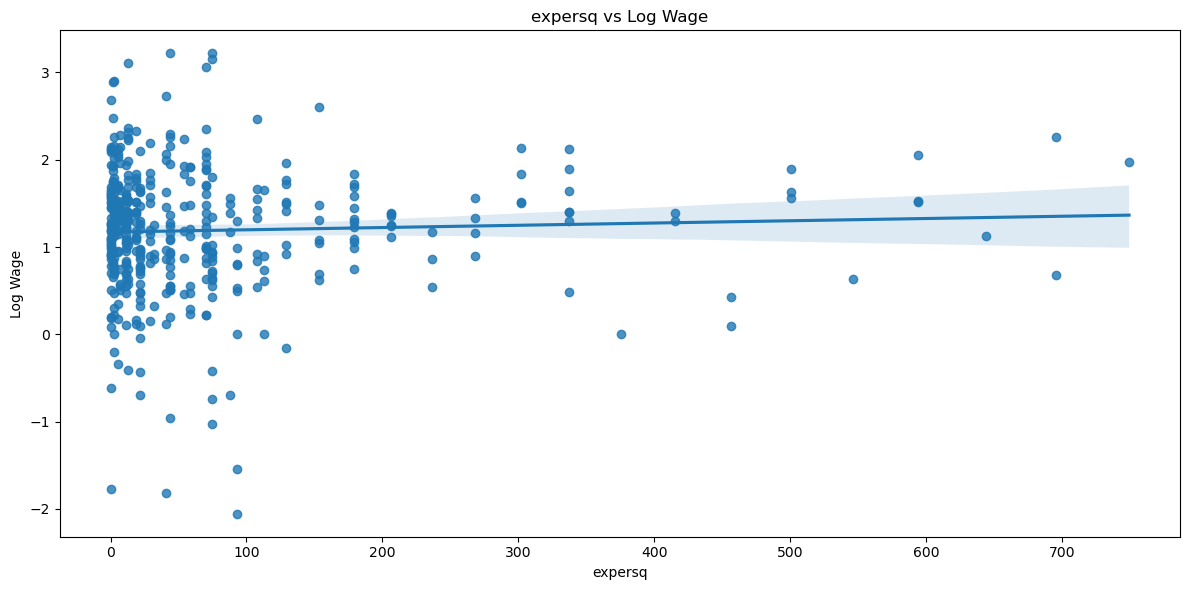

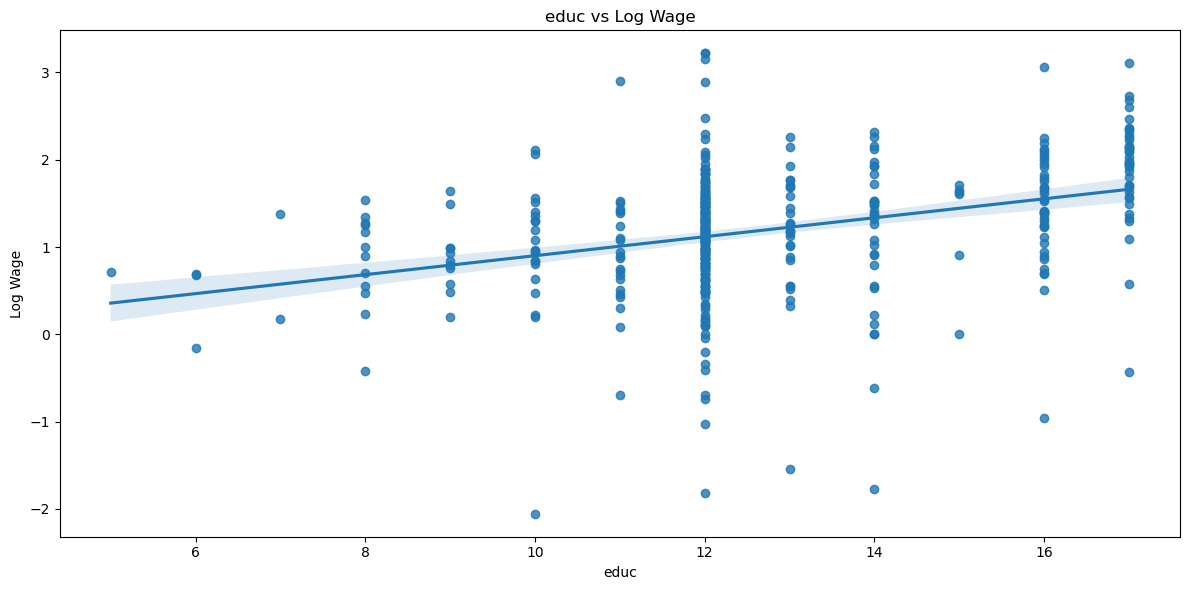

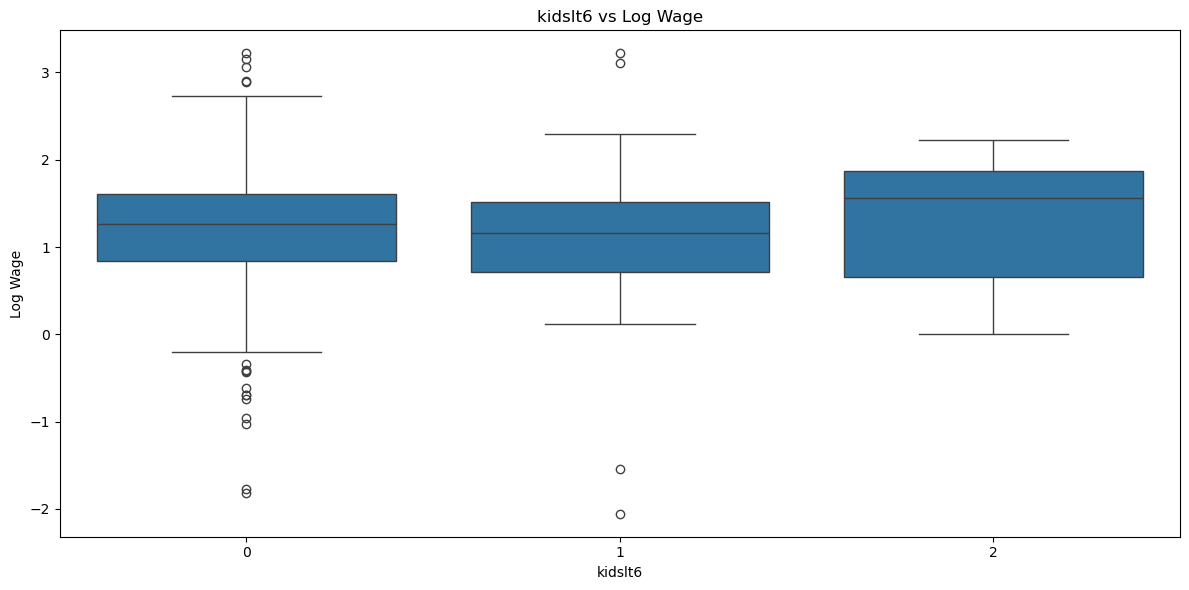

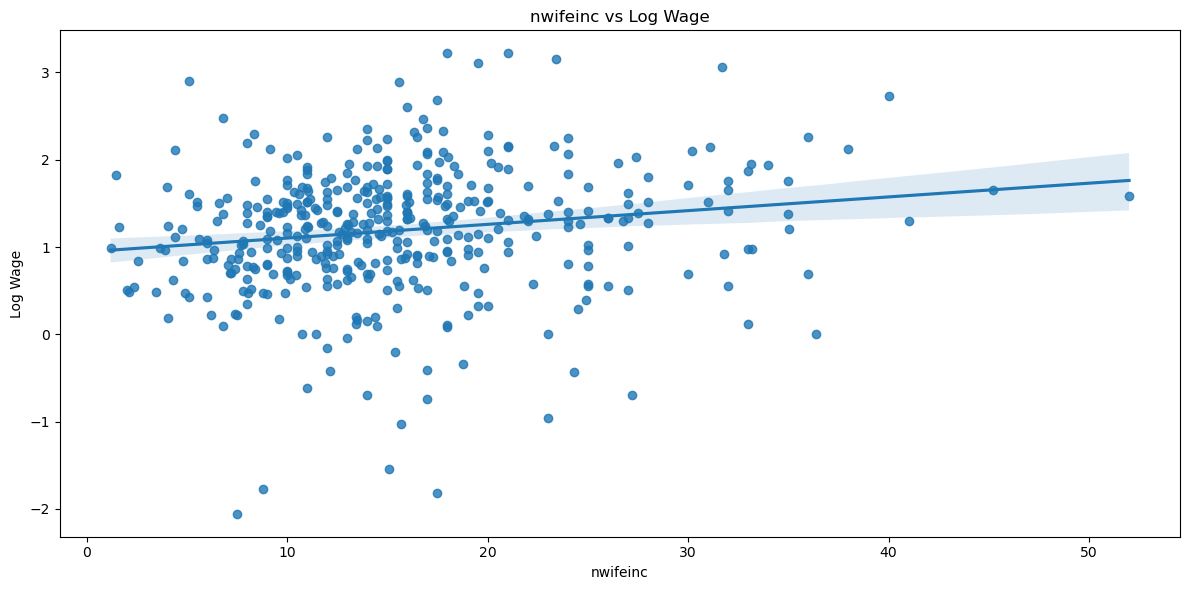

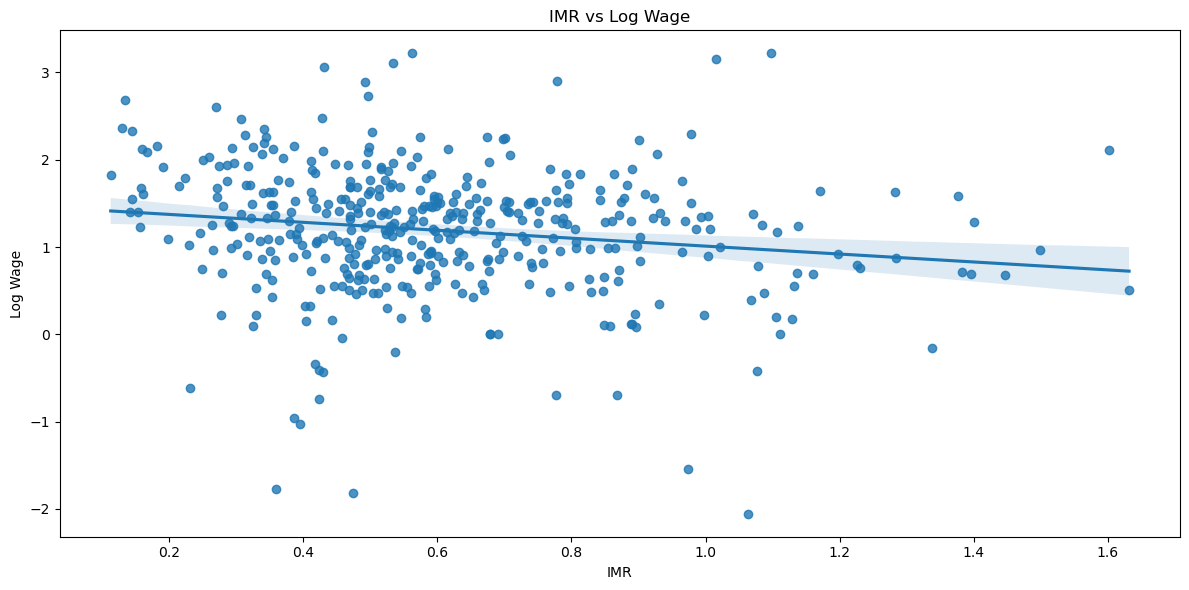

In [ ]:
def make_regplot(obj: MrozHandler, col: pd.Series) -> plt.Axes | None:
    fig, ax = plt.subplots(figsize=(12, 6))
    
    y_data = obj.dependent
    xlabel = col.name
    ylabel = y_data.name
        
    plot_df = pd.DataFrame({xlabel: col.values, ylabel: y_data.values})
    
    if col.nunique() <= 5:
        sns.boxplot(data=plot_df, x=xlabel, y=ylabel, ax=ax)
    else:
        sns.regplot(data=plot_df, x=xlabel, y=ylabel, ax=ax)
    
    ax.set_title(f"{xlabel} vs Log Wage")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Log Wage")
    plt.tight_layout()
    return ax


def make_boxplots_by_group(obj: MrozHandler, col: pd.Series, group_col: pd.Series) -> plt.Figure:
    groups = sorted(group_col.unique())
    fig, axes = plt.subplots(1, len(groups), figsize=(6 * len(groups), 6), sharey=True)
    
    if len(groups) == 1:
        axes = [axes]
    
    y_data = obj.dependent
    ylabel = y_data.name
    xlabel = col.name
    group_name = group_col.name
    
    full_df = pd.DataFrame({
        xlabel: col.values,
        ylabel: y_data.values,
        group_name: group_col.values
    })
    
    for ax, group_val in zip(axes, groups):
        subset = full_df[full_df[group_name] == group_val]
        sns.boxplot(data=subset, x=xlabel, y=ylabel, ax=ax)
        ax.set_title(f"{xlabel} vs {ylabel} ({group_name} = {group_val})")
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel if ax == axes[0] else "")
    
    fig.suptitle(f"{xlabel} vs {ylabel} by {group_name}", fontsize=14, y=1.02)
    plt.tight_layout()
    return fig


def regplot_generator(obj: MrozHandler):
    kidslt6 = None
    for c in obj.independents + obj.controls:
        if c.name == "kidslt6":
            kidslt6 = c
            break
    for col in obj.independents + obj.controls:
        if col.name == "kidslt6":
            yield make_regplot(obj, col)  # boxplot of kidslt6 vs y
        elif kidslt6 is not None and col.nunique() <= 5:
            yield make_boxplots_by_group(obj, col, kidslt6)  # boxplots split by kidslt6
        else:
            yield make_regplot(obj, col)

for plot in regplot_generator(Mroz):
    plt.show()

## Requirement 3: Outlier Detection (Robust Statistics)

In [6]:
def find_outliers(obj:MrozHandler, var:str):
    # Manual Tukey Fence implementation
    Q1 = obj.full[var].quantile(0.25)
    Q3 = obj.full[var].quantile(0.75)
    IQR = Q3 - Q1

    outliers = obj.full[(obj.full[var] < (Q1 - 1.5 * IQR)) | (obj.full[var] > (Q3 + 1.5 * IQR))]

    return outliers

def outlier_report(obj: MrozHandler):
    for col in obj.independents + obj.controls:
        name = col.name
        outliers = find_outliers(obj, name)
        print(f"\n{'='*40}")
        print(f"  {name} (unique: {col.nunique()})")
        print(f"{'='*40}")
        if outliers.empty:
            print("  No outliers detected.")
        else:
            print(f"  {len(outliers)} outliers found")
            print(f"  Range: [{col.min()}, {col.max()}]")
            print(f"  Outlier values: {sorted(outliers[name].unique())}")

outlier_report(Mroz)


  exper (unique: 39)
  16 outliers found
  Range: [0, 38]
  Outlier values: [np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(45)]

  expersq (unique: 39)
  63 outliers found
  Range: [0.13630118745910536, 749.0725561675387]
  Outlier values: [np.float64(178.73523877046043), np.float64(206.47361858453746), np.float64(236.21199839861447), np.float64(267.9503782126914), np.float64(301.6887580267685), np.float64(337.4271378408455), np.float64(375.1655176549225), np.float64(414.9038974689995), np.float64(456.64227728307657), np.float64(500.3806570971536), np.float64(546.1190369112306), np.float64(593.8574167253076), np.float64(643.5957965393847), np.float64(695.3341763534617), np.float64(749.0725561675387), np.float64(1181.2412148660778)]

  educ (unique: 13)
  234 outliers found
  Range: [5, 17]
  Outlier values: [np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(15), np.int64(16), np.int64(17

## Redo Requirement #2 with Outliers Highlighted

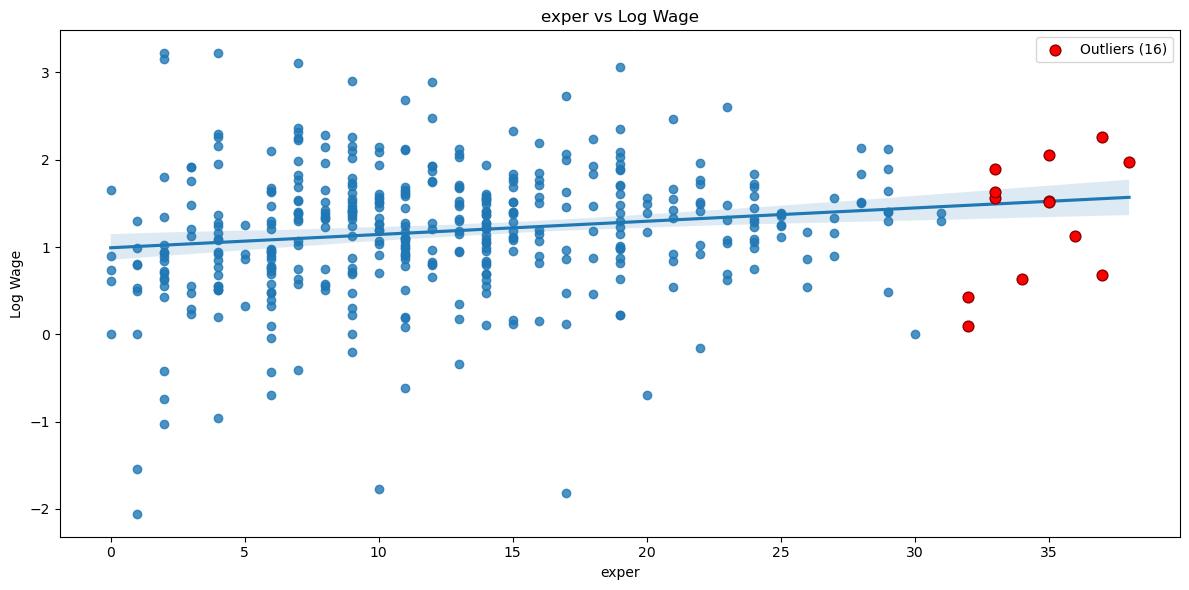

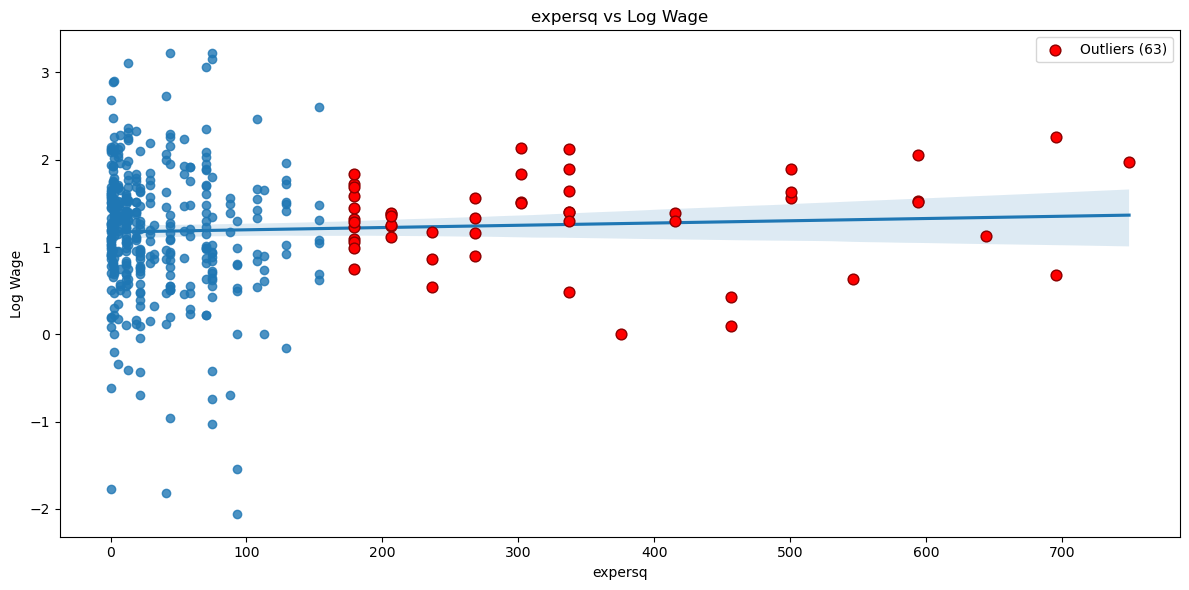

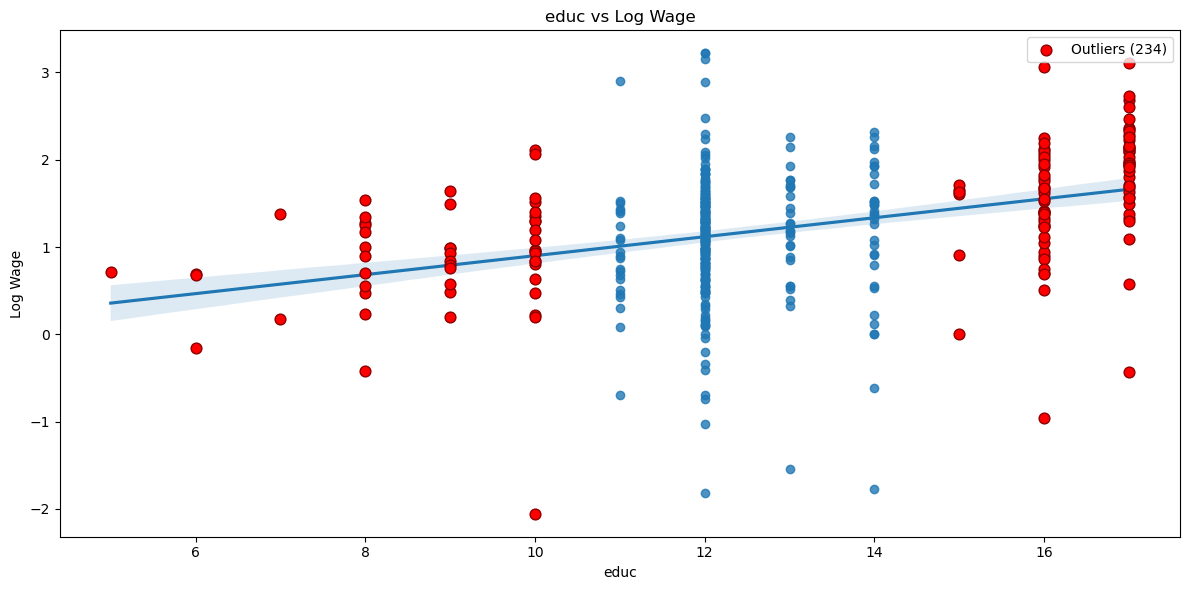

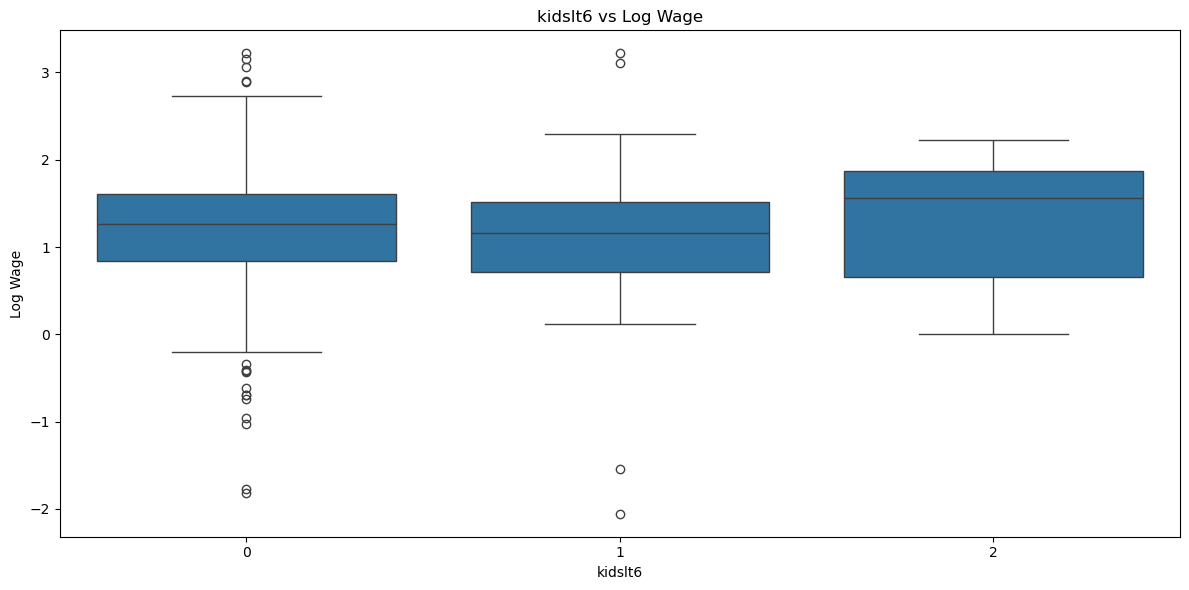

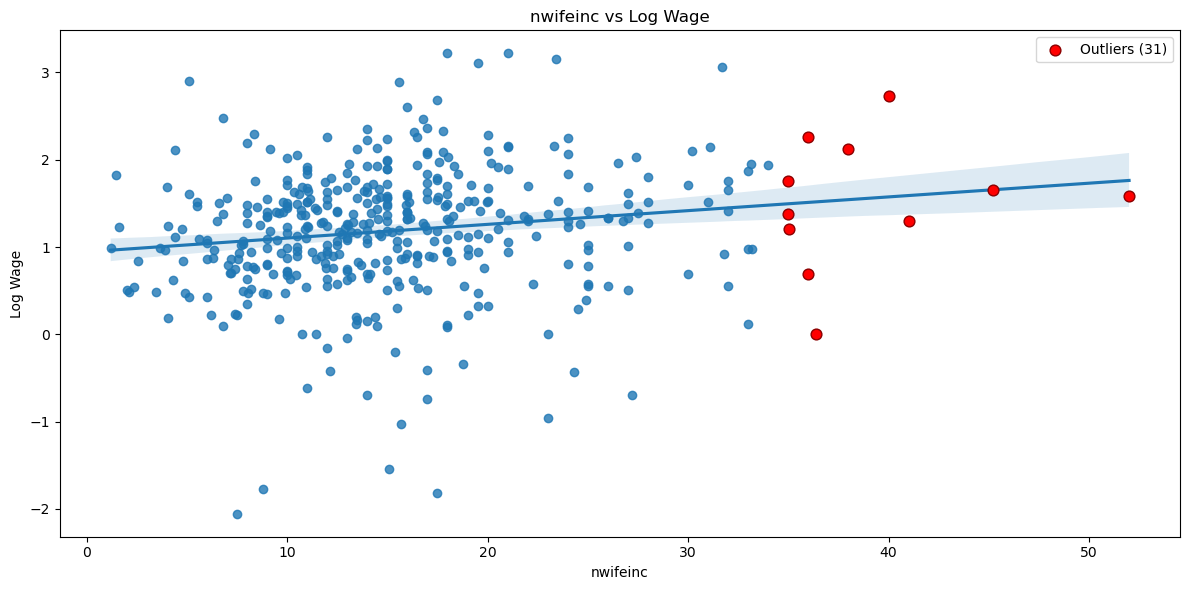

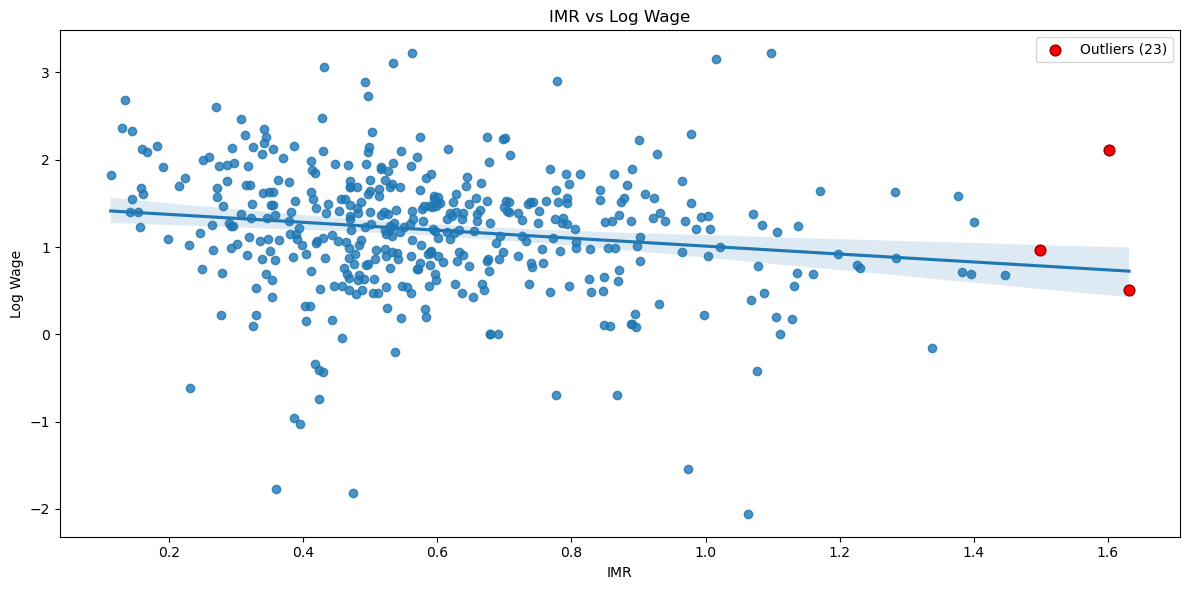

In [7]:
def make_regplot(obj: MrozHandler, col: pd.Series) -> plt.Axes | None:
    fig, ax = plt.subplots(figsize=(12, 6))
    
    y_data = obj.dependent
    xlabel = col.name
    ylabel = y_data.name
        
    plot_df = pd.DataFrame({xlabel: col.values, ylabel: y_data.values})
    
    if col.nunique() <= 5:
        sns.boxplot(data=plot_df, x=xlabel, y=ylabel, ax=ax)
    else:
        sns.regplot(data=plot_df, x=xlabel, y=ylabel, ax=ax)
        
        # overlay outliers in red
        outliers = find_outliers(obj, xlabel)
        if not outliers.empty:
            ax.scatter(
                outliers[xlabel], outliers[ylabel],
                color='red', s=60, zorder=5, label=f'Outliers ({len(outliers)})', edgecolors='darkred'
            )
            ax.legend()
    
    ax.set_title(f"{xlabel} vs Log Wage")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Log Wage")
    plt.tight_layout()
    return ax

for plot in regplot_generator(Mroz):
    plt.show()
